In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

project_root = Path.cwd().resolve()
DATA_RAW = project_root / "data" / "raw"

print("Project root:", project_root)
print("Raw path:", DATA_RAW)

Project root: C:\Users\matee\OneDrive\Documents\winter\applied_data_science\final-project-matee786313rehman\lactate_ml_project
Raw path: C:\Users\matee\OneDrive\Documents\winter\applied_data_science\final-project-matee786313rehman\lactate_ml_project\data\raw


In [2]:
df = pd.read_csv(DATA_RAW / "dta_raw.csv")

print(df.shape)
df.head()

(201, 91)


,pt_srl_no,dob,gender,ges_age,age,bw,premature,weight,cicu_diag,hosp_los,...,trnsfsn,pd_drain,nirs_so2_1,cvp_1,nirs_so2_2,cvp_2,nirs_so2_3,cvp_3,nirs_so2_4,cvp_4
0,p001,7/24/2016,Male,39.0,12,2.640,No,2.640,VSD + Aortic arch hypoplasia,22,...,20.00,0.0,46.0,7.0,67.0,8.0,76.0,10.0,75.0,12.0
1,p002,11/3/2024,Male,39.0,5,3.425,No,3.425,"TOF, Pulmonary stenosis",22,...,0.00,0.0,95.0,0.0,66.0,0.0,78.0,0.0,78.0,0.0
2,p003,11/6/2024,Male,39.0,3,3.060,No,3.000,Total anomalous pulmonary venous connection (T...,26,...,0.00,0.0,80.0,0.0,76.0,0.0,75.0,0.0,79.0,0.0
3,p004,11/11/2024,Male,32.0,5,2.114,Yes,2.114,"TGA, VSD",72,...,254.00,0.0,61.0,0.0,61.0,0.0,68.0,0.0,68.0,0.0
4,p005,11/16/2024,Male,40.0,5,3.465,No,3.465,"TGA, IVS",111,...,185.68,0.0,57.0,6.0,0.0,0.0,0.0,11.0,75.0,0.0


In [3]:
df.columns.tolist()

['pt_srl_no',
 'dob',
 'gender',
 'ges_age',
 'age',
 'bw',
 'premature',
 'weight',
 'cicu_diag',
 'hosp_los',
 'cpb_time',
 'x_clamp',
 'stat_cat',
 'crrt',
 'nitric_ox',
 'vas_final_cicu_end',
 'vasop_2hr',
 'vaso_inf',
 'vis',
 'lcos_if_2',
 'lcos_post_2',
 'mortality_dc',
 'readmit_30',
 'pge_inf',
 'mil_admin',
 'ino_vaso_agent_admin',
 'epi_admin',
 'hyd_admin',
 'synd',
 'synd_13',
 'synd_18',
 'synd_21',
 'chrom_a',
 'chrom_a_22q11',
 'iop_ecmo',
 'comp_ecmo',
 'ecpr',
 'cmc_spp',
 'cmc_dur',
 'vent_mech',
 'vent_dur',
 'glu_1',
 'lact_prio',
 'lactate_peak',
 'hct_1',
 'hct_peak',
 'bun_1',
 'creatinine_1',
 'albu_1',
 'alt_1',
 'tot_bili_1',
 'cap_refill_t',
 'cap_refill_t2',
 'bicarb_1',
 'glu_2',
 'lactate_1',
 'hct_2',
 'pt_inr_1',
 'bicarb_2',
 'glu_3',
 'lactate_2',
 'hct_3',
 'pt_inr_2',
 'bicarb_3',
 'glu_4',
 'lactate_3',
 'hct_4',
 'pt_inr_3',
 'bicarb_4',
 'glu_5',
 'lactate_4',
 'hct_5',
 'bun_2',
 'creatinine_2',
 'pt_inr_4',
 'map_1',
 'map_2',
 'map_3',
 'map_4

In [4]:
vars_to_fix = [
    "glu_1","lact_prio","lactate_peak","hct_1","hct_peak",
    "bun_1","creatinine_1","albu_1","alt_1","tot_bili_1",
    "cap_refill_t","cap_refill_t2","bicarb_1","glu_2",
    "lactate_1","hct_2","pt_inr_1","bicarb_2","glu_3",
    "lactate_2","hct_3","pt_inr_2","bicarb_3","glu_4",
    "lactate_3","hct_4","pt_inr_3","bicarb_4","glu_5",
    "lactate_4","hct_5","bun_2","creatinine_2","pt_inr_4",
    "map_1","map_2","map_3","map_4","urine_3",
    "fluid_admin","trnsfsn","pd_drain",
    "nirs_so2_1","cvp_1","nirs_so2_2","cvp_2",
    "nirs_so2_3","cvp_3","nirs_so2_4","cvp_4"
]

df[vars_to_fix] = df[vars_to_fix].replace(0, np.nan)
(df[vars_to_fix] == 0).sum().sum()

np.int64(0)

In [5]:
y = df["lactate_3"]
features = [
    "lactate_1", "lactate_2",
    "hct_1", "hct_2",
    "map_1", "map_2",
    "vasop_2hr", "vas_final_cicu_end",
    "cpb_time", "x_clamp", "stat_cat",
    "age", "bw", "premature"
]
X = df[features]
y = df["lactate_3"]

print(X.shape, y.shape)

(201, 14) (201,)


In [6]:
df["premature"].unique()
prem = (
    df["premature"]
    .astype(str)
    .str.strip()
    .str.lower()
)
prem = prem.map({
    "yes": 1,
    "no": 0,
    "unk": np.nan
})
X["premature"] = prem
X["premature"].value_counts(dropna=False)

premature
0.0    171
1.0     29
NaN      1
Name: count, dtype: int64

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [10]:
X_imputed = imputer.fit_transform(X)
X_imputed.shape

(201, 14)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.9780267466041869
R2: 0.5734031048864222


In [13]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear RMSE:", rmse_lin)
print("Linear R2:", r2_lin)

Linear RMSE: 0.9122132146731797
Linear R2: 0.6288846267105721


In [19]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values(ascending=False).head(5)

lactate_2    0.648710
cpb_time     0.050657
map_1        0.047206
x_clamp      0.043200
lactate_1    0.041764
dtype: float64

<Axes: >

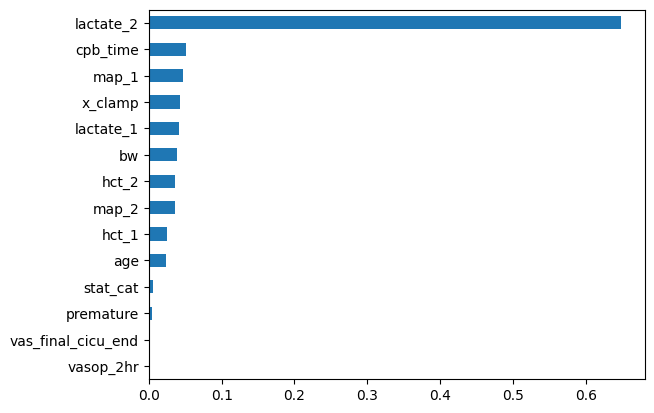

In [20]:
importances.sort_values().plot(kind="barh")

In [23]:
coef = pd.Series(lin_model.coef_, index=features)
coef.sort_values()

bw                   -1.345477e-01
age                  -2.142394e-02
map_2                -1.645780e-02
map_1                -1.267945e-02
cpb_time             -7.604915e-03
hct_1                -5.884247e-03
lactate_1            -5.525225e-03
vasop_2hr            -9.436896e-16
hct_2                 5.885401e-06
x_clamp               4.752383e-03
stat_cat              4.622011e-02
premature             5.376860e-02
vas_final_cicu_end    6.323350e-01
lactate_2             7.315440e-01
dtype: float64

In [24]:
coef.sort_values(ascending=False).head(5)

lactate_2             0.731544
vas_final_cicu_end    0.632335
premature             0.053769
stat_cat              0.046220
x_clamp               0.004752
dtype: float64